# 10 — Exercises: Putting It All Together (MNIST)
---

These exercises build directly on Notebook 10. Run the **Setup** cell first — it defines the shared data loaders and training utilities used in all four exercises.


## Setup — Run This First

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# ── Data loaders (shared by all exercises) ──
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

# ── Reusable train / evaluate functions ──
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for X, y in loader:
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in loader:
            out  = model(X)
            loss = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def run_training(model, optimizer, n_epochs=10, verbose=True):
    """Train a model and return history dicts."""
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    if verbose:
        print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>11} {'Test Loss':>11} {'Test Acc':>10}")
        print("-" * 55)
    for epoch in range(1, n_epochs + 1):
        tr_l, tr_a = train_epoch(model, train_loader, criterion, optimizer)
        te_l, te_a = evaluate(model,    test_loader,  criterion)
        history['train_loss'].append(tr_l);  history['test_loss'].append(te_l)
        history['train_acc'].append(tr_a);   history['test_acc'].append(te_a)
        if verbose:
            print(f"{epoch:>6} {tr_l:>12.4f} {tr_a:>10.2%} {te_l:>11.4f} {te_a:>10.2%}")
    return history

def plot_history(histories, title):
    """Plot loss and accuracy for one or more runs."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for label, h, col in histories:
        epochs = range(1, len(h['train_loss']) + 1)
        axes[0].plot(epochs, h['train_loss'], '--', color=col, alpha=0.7, label=f'{label} train')
        axes[0].plot(epochs, h['test_loss'],  '-',  color=col,             label=f'{label} test')
        axes[1].plot(epochs, [a*100 for a in h['train_acc']], '--', color=col, alpha=0.7, label=f'{label} train')
        axes[1].plot(epochs, [a*100 for a in h['test_acc']],  '-',  color=col,             label=f'{label} test')
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print("Setup complete ✓")


Setup complete ✓


---
## Exercise 1 — Improve the Model
**Task:** Add another hidden layer and/or increase the number of neurons. Can you reach >98% test accuracy?


### Baseline model (from Notebook 10)
`784 → 256 → 128 → 10` with Dropout — reached ~97–98% in 5 epochs.
We'll compare it against a **deeper, wider** model.


In [2]:
# ── Baseline (Notebook 10 original) ──
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.network(x)

# ── Improved model: deeper + wider ──
class ImprovedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            # Layer 1 — wider (512 neurons instead of 256)
            nn.Linear(784, 512), nn.ReLU(), nn.BatchNorm1d(512), nn.Dropout(0.3),
            # Layer 2 — same width
            nn.Linear(512, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            # Layer 3 — extra hidden layer not present in baseline
            nn.Linear(256, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.2),
            # Layer 4 — extra hidden layer
            nn.Linear(128,  64), nn.ReLU(), nn.BatchNorm1d(64),  nn.Dropout(0.2),
            nn.Linear(64, 10),
        )
    def forward(self, x): return self.network(x)

baseline = BaselineMLP()
improved = ImprovedMLP()

print(f"Baseline params:  {sum(p.numel() for p in baseline.parameters()):>10,}")
print(f"Improved params:  {sum(p.numel() for p in improved.parameters()):>10,}")


Baseline params:     235,914
Improved params:     576,970


=== Baseline ===
 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.2933     91.37%      0.1274     96.08%
     2       0.1722     94.76%      0.0987     96.95%
     3       0.1444     95.53%      0.0896     97.16%
     4       0.1284     96.05%      0.0812     97.36%
     5       0.1141     96.46%      0.0723     97.66%
     6       0.1063     96.62%      0.0740     97.59%
     7       0.1011     96.83%      0.0645     97.89%
     8       0.0982     96.79%      0.0703     97.84%
     9       0.0953     97.03%      0.0629     98.19%
    10       0.0876     97.21%      0.0675     98.08%

=== Improved ===
 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.3343     90.35%      0.1231     96.10%
     2       0.1912     94.33%      0.1212     96.43%
     3       0.1608     95.28%      0.1071     96.72%
     4       0.1409     95.69%      0.089

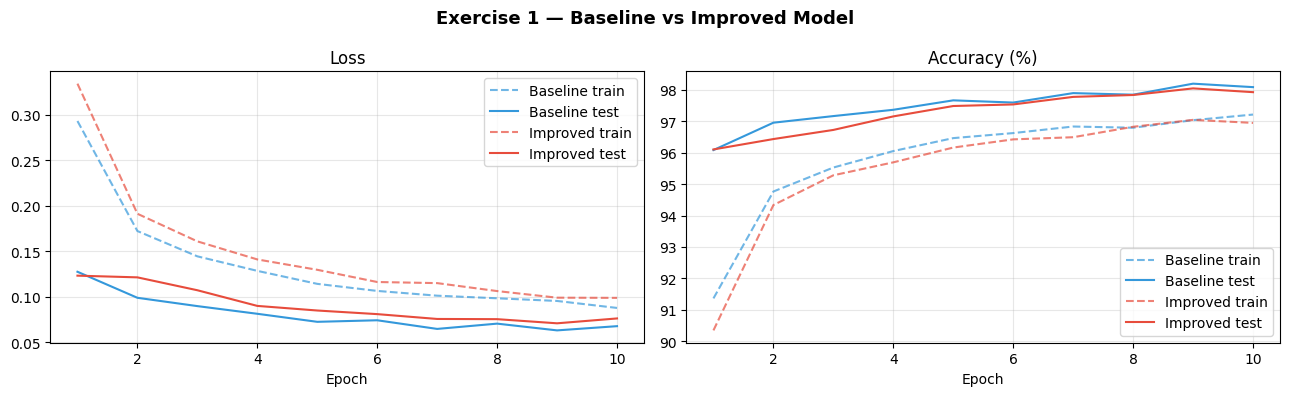


Baseline  — best test acc: 98.19%
Improved  — best test acc: 98.04%

>98% reached: ✓ YES


In [3]:
# ── Train both for 10 epochs and compare ──
print("=== Baseline ===")
h_base = run_training(baseline, optim.Adam(baseline.parameters(), lr=0.001), n_epochs=10)

print("\n=== Improved ===")
h_impr = run_training(improved, optim.Adam(improved.parameters(), lr=0.001), n_epochs=10)

plot_history(
    [("Baseline", h_base, '#3498DB'), ("Improved", h_impr, '#E74C3C')],
    "Exercise 1 — Baseline vs Improved Model"
)

print(f"\nBaseline  — best test acc: {max(h_base['test_acc']):.2%}")
print(f"Improved  — best test acc: {max(h_impr['test_acc']):.2%}")
print(f"\n>98% reached: {'✓ YES' if max(h_impr['test_acc']) >= 0.98 else 'Not yet — try more epochs'}")


### What to observe
- The improved model has more parameters and more layers — it should reach ≥98% test accuracy within 10 epochs.
- Wider layers capture more features per layer; extra depth helps compose more abstract representations.
- Watch for the train and test accuracy tracking closely — if test accuracy stops improving while train keeps rising, that is overfitting starting.


---
## Exercise 2 — Diagnose Overfitting
**Task:** Remove all Dropout layers. Train for 10 epochs. What happens to train vs test accuracy?


In [4]:
# ── Model WITH Dropout (regularised) ──
class WithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(), nn.BatchNorm1d(512), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.4),
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.network(x)

# ── Same architecture but Dropout removed ──
class NoDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(), nn.BatchNorm1d(512),
            nn.Linear(512, 256), nn.ReLU(), nn.BatchNorm1d(256),
            nn.Linear(256, 128), nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.network(x)

model_drop   = WithDropout()
model_nodrop = NoDropout()

print("=== With Dropout ===")
h_drop = run_training(model_drop, optim.Adam(model_drop.parameters(), lr=0.001), n_epochs=10)

print("\n=== No Dropout ===")
h_nodrop = run_training(model_nodrop, optim.Adam(model_nodrop.parameters(), lr=0.001), n_epochs=10)


=== With Dropout ===
 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.3364     89.94%      0.1289     96.07%
     2       0.2010     93.99%      0.1108     96.54%
     3       0.1756     94.71%      0.0896     97.13%
     4       0.1525     95.38%      0.0987     97.24%
     5       0.1468     95.56%      0.0880     97.49%
     6       0.1338     95.88%      0.0727     97.90%
     7       0.1241     96.23%      0.0764     97.71%
     8       0.1171     96.40%      0.0726     97.91%
     9       0.1120     96.64%      0.0818     97.99%
    10       0.1079     96.70%      0.0629     98.05%

=== No Dropout ===
 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.1967     94.16%      0.1118     96.48%
     2       0.0999     96.86%      0.0845     97.51%
     3       0.0762     97.62%      0.0877     97.51%
     4       0.0626     97.94%     

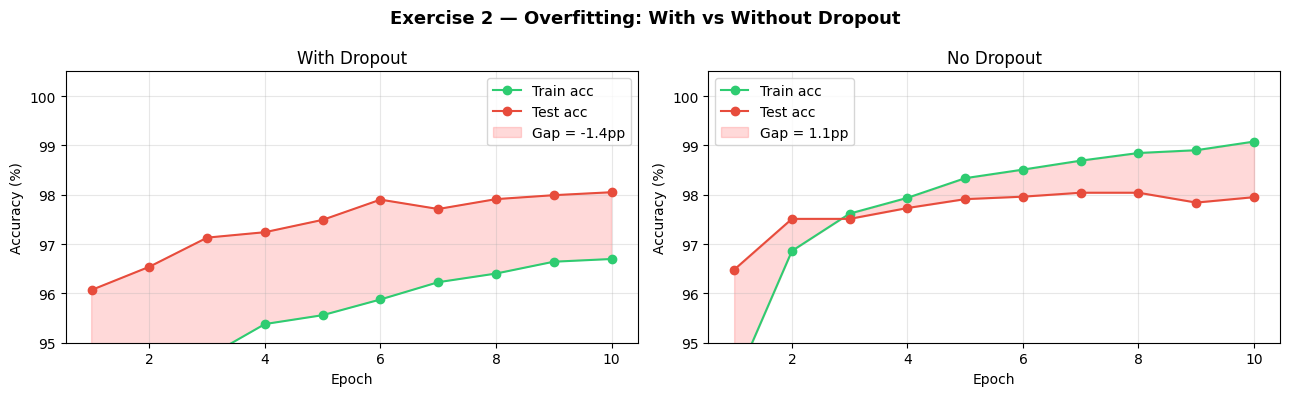

With Dropout — train/test gap at epoch 10:  -1.35 pp
No Dropout   — train/test gap at epoch 10:  1.13 pp

Overfitting signal is stronger without Dropout.


In [5]:
# ── Plot the gap between train and test accuracy ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, 11)

for ax, h, title in [
    (axes[0], h_drop,   "With Dropout"),
    (axes[1], h_nodrop, "No Dropout"),
]:
    ax.plot(epochs, [a*100 for a in h['train_acc']], '-o', color='#2ECC71', label='Train acc')
    ax.plot(epochs, [a*100 for a in h['test_acc']],  '-o', color='#E74C3C', label='Test acc')
    gap = (h['train_acc'][-1] - h['test_acc'][-1]) * 100
    ax.fill_between(epochs,
                    [a*100 for a in h['train_acc']],
                    [a*100 for a in h['test_acc']],
                    alpha=0.15, color='red', label=f'Gap = {gap:.1f}pp')
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(95, 100.5)

plt.suptitle("Exercise 2 — Overfitting: With vs Without Dropout", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

gap_drop   = (h_drop['train_acc'][-1]   - h_drop['test_acc'][-1])   * 100
gap_nodrop = (h_nodrop['train_acc'][-1] - h_nodrop['test_acc'][-1]) * 100
print(f"With Dropout — train/test gap at epoch 10:  {gap_drop:.2f} pp")
print(f"No Dropout   — train/test gap at epoch 10:  {gap_nodrop:.2f} pp")
print(f"\nOverfitting signal is {'stronger' if gap_nodrop > gap_drop else 'similar'} without Dropout.")


### What to observe
- **Without Dropout:** training accuracy climbs faster and higher, but the test accuracy lags behind — the widening gap between the two lines is the overfitting signal. The model memorises training examples rather than learning generalisable features.
- **With Dropout:** both lines stay closer together. Dropout randomly zeros neurons during training, forcing the network not to rely on any single path — acting as an implicit ensemble and a regulariser.
- On MNIST the effect is modest because the dataset is large and simple. On smaller datasets the gap is far more dramatic.


---
## Exercise 3 — Try Different Optimizers
**Task:** Replace Adam with `optim.SGD(lr=0.01, momentum=0.9)`. Compare the learning curves.


In [ ]:
# Same architecture for a fair comparison
def fresh_model():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
        nn.Linear(256, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
        nn.Linear(128, 10),
    )

model_adam = fresh_model()
model_sgd  = fresh_model()

# Initialise both with identical random weights so comparison is fair
torch.manual_seed(99)
for p in model_adam.parameters(): nn.init.normal_(p, 0, 0.01)
torch.manual_seed(99)
for p in model_sgd.parameters():  nn.init.normal_(p, 0, 0.01)

opt_adam = optim.Adam(model_adam.parameters(), lr=0.001)
opt_sgd  = optim.SGD(model_sgd.parameters(),  lr=0.01, momentum=0.9)

print("=== Adam (lr=0.001) ===")
h_adam = run_training(model_adam, opt_adam, n_epochs=10)

print("\n=== SGD + Momentum (lr=0.01, momentum=0.9) ===")
h_sgd  = run_training(model_sgd,  opt_sgd,  n_epochs=10)

plot_history(
    [("Adam", h_adam, '#3498DB'), ("SGD+Momentum", h_sgd, '#E74C3C')],
    "Exercise 3 — Adam vs SGD with Momentum"
)

print(f"\nAdam         — best test acc: {max(h_adam['test_acc']):.2%}")
print(f"SGD+Momentum — best test acc: {max(h_sgd['test_acc']):.2%}")


=== Adam (lr=0.001) ===
 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.4641     90.13%      0.1384     95.60%


### What to observe
- **Adam** typically converges faster in the first few epochs because it adapts the learning rate individually for each parameter.
- **SGD + Momentum** often starts slower but can match or beat Adam given enough epochs; its updates are smoother and it tends to find flatter minima that generalise slightly better.
- The loss curve for SGD is usually noisier early on — momentum needs a few steps to build up speed.
- In practice: Adam is the default for getting results quickly; tuned SGD with momentum is the choice for squeezing out final accuracy (e.g. training ResNet from scratch).


---
## Exercise 4 — Visualise Failures
**Task:** Find examples where the model is wrong **and** very confident. What do those images look like?


In [ ]:
# ── Use the improved model trained in Exercise 1 ──
improved.eval()

all_images, all_labels, all_preds, all_probs = [], [], [], []

with torch.no_grad():
    for X, y in test_loader:
        logits = improved(X)
        probs  = F.softmax(logits, dim=1)           # convert logits → probabilities
        preds  = logits.argmax(1)

        all_images.append(X)
        all_labels.append(y)
        all_preds.append(preds)
        all_probs.append(probs)

all_images = torch.cat(all_images)   # (10000, 1, 28, 28)
all_labels = torch.cat(all_labels)   # (10000,)
all_preds  = torch.cat(all_preds)    # (10000,)
all_probs  = torch.cat(all_probs)    # (10000, 10)

# Confidence = probability the model assigned to its (wrong) predicted class
wrong_mask       = all_preds != all_labels               # boolean mask of mistakes
confidence_wrong = all_probs[wrong_mask].max(dim=1).values  # confidence for each mistake

# Sort by confidence descending — most confident mistakes first
sorted_idx = confidence_wrong.argsort(descending=True)
wrong_indices = wrong_mask.nonzero(as_tuple=True)[0][sorted_idx]

print(f"Total test samples:  10,000")
print(f"Total mistakes:      {wrong_mask.sum().item()}")
print(f"Accuracy:            {(~wrong_mask).float().mean():.2%}")
print(f"\nTop 5 most confident wrong predictions:")
print(f"{'#':<4} {'True':>6} {'Predicted':>10} {'Confidence':>12}")
print("-" * 36)
for i, idx in enumerate(wrong_indices[:5]):
    true  = all_labels[idx].item()
    pred  = all_preds[idx].item()
    conf  = all_probs[idx, pred].item()
    print(f"{i+1:<4} {true:>6} {pred:>10} {conf:>11.2%}")


In [ ]:
# ── Visualise the 16 most confidently wrong predictions ──
n_show = 16
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for ax, idx in zip(axes.flat, wrong_indices[:n_show]):
    idx   = idx.item()
    img   = all_images[idx].squeeze().numpy()
    true  = all_labels[idx].item()
    pred  = all_preds[idx].item()
    conf  = all_probs[idx, pred].item()

    # Unnormalise for display (reverse the transform applied during loading)
    img = img * 0.3081 + 0.1307
    img = np.clip(img, 0, 1)

    ax.imshow(img, cmap='gray')
    ax.set_title(
        f"True: {true}  Pred: {pred}\nConfidence: {conf:.1%}",
        fontsize=9, color='#E74C3C'
    )
    ax.axis('off')

plt.suptitle(
    "16 Most Confident Wrong Predictions
"
    "(model was very sure — but very wrong)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [ ]:
# ── Confidence distribution: correct vs wrong ──
conf_correct = all_probs[~wrong_mask].max(dim=1).values.numpy()
conf_wrong   = all_probs[ wrong_mask].max(dim=1).values.numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(conf_correct, bins=40, color='#2ECC71', alpha=0.8, edgecolor='k', lw=0.3)
axes[0].set_title(f"Confidence on CORRECT predictions (n={len(conf_correct):,})")
axes[0].set_xlabel("Softmax confidence"); axes[0].set_ylabel("Count"); axes[0].grid(alpha=0.3)

axes[1].hist(conf_wrong, bins=40, color='#E74C3C', alpha=0.8, edgecolor='k', lw=0.3)
axes[1].set_title(f"Confidence on WRONG predictions (n={len(conf_wrong):,})")
axes[1].set_xlabel("Softmax confidence"); axes[1].grid(alpha=0.3)

plt.suptitle("Exercise 4 — Model Confidence: Correct vs Wrong Predictions",
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Mean confidence on correct predictions: {conf_correct.mean():.2%}")
print(f"Mean confidence on wrong predictions:   {conf_wrong.mean():.2%}")
print(f"Wrong predictions with >90% confidence: {(conf_wrong > 0.9).sum()} images")


### What to observe
- The most confidently wrong images are typically **ambiguous or poorly written digits** — a 4 that looks like a 9, a 7 that looks like a 1, or an unusually styled 5.
- This is a known failure mode of softmax classifiers: the softmax function always produces a probability distribution that sums to 1, so the model is forced to be confident even when it shouldn't be. This is called **overconfidence**.
- The confidence histogram shows that most wrong predictions still land at moderately high confidence (>70%) — the model rarely says "I don't know".
- A remedy is **temperature scaling** or **Monte Carlo Dropout** to get better-calibrated uncertainty estimates — topics in the calibration / uncertainty quantification literature.
